Feature encoding is a crucial step in data preprocessing, especially when dealing with categorical variables. It transforms categorical data into numerical format so that machine learning models can interpret and process it effectively. Let’s break this down step by step.

**Why is Feature Encoding Needed?**
- Machine learning models work with numerical data. However, datasets often contain categorical variables like:

- Nominal Categories (No intrinsic order): Example - Colors (Red, Blue, Green), Gender (Male, Female, Other)

- Ordinal Categories (Ordered relationship): Example - Education Level (High School < Bachelor < Master < PhD)

Encoding converts these categories into numbers while preserving as much information as possible.

#  Types of Feature Encoding
There are multiple encoding techniques, each with its own advantages and use cases.

## Label Encoding
Assigns a unique integer to each category.

**Pros:** Simple and memory-efficient.

**Cons:** Implies an ordinal relationship where none exists (e.g., "Red" < "Blue" < "Green"), which may mislead models.

### Why is Label Encoding Problematic for Nominal Data?
Label encoding assigns numerical values to categories, but this can mislead machine learning models when the categories don’t have an inherent order.

**📌 Example 1: Colors (Nominal Data)**
Let's say we have a dataset with a categorical feature Color:

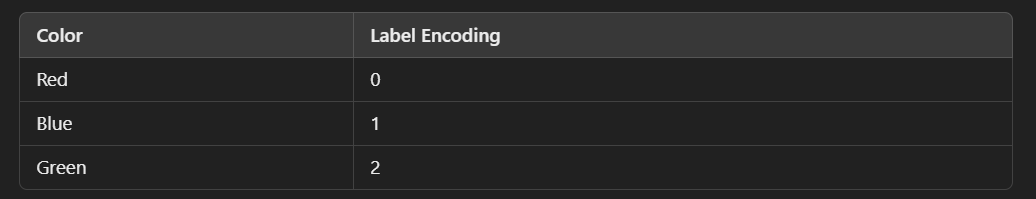

Now, if we use this encoding in a machine learning model (e.g., Linear Regression or Decision Tree), the model might interpret these values as:

- Red < Blue < Green
- 0 < 1 < 2, meaning it assumes that Green is greater than Blue, and Blue is greater than Red
- But in reality, colors don’t have a numerical order! 🚨

This wrong assumption can negatively impact distance-based models like KNN, SVM, and linear models because they will treat Red and Blue as closer than Red and Green, which isn’t meaningful.

**📌 Example 2: Education Level (Ordinal Data)**
Now, consider Education Level, which has a natural order:

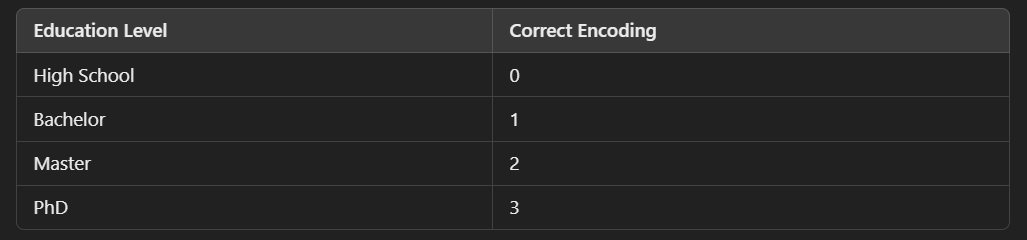

Here, using Label Encoding is fine because higher education levels do imply an increasing order.

- PhD (3) > Master (2) > Bachelor (1) > High School (0)
- This makes sense because higher education levels are progressively more advanced.



In [1]:
# misleading

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
colors = ['Red', 'Blue', 'Green', 'Blue', 'Red']
encoded_colors = le.fit_transform(colors)
print(encoded_colors)  # Output: [2 0 1 0 2]


[2 0 1 0 2]


In [2]:
# Label Encoding: Natural order exists
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.DataFrame({'Size': ['Small', 'Medium', 'Large']})

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'Size' column
data['Size_encoded'] = label_encoder.fit_transform(data['Size'])
data

,Size,Size_encoded
0,Small,2
1,Medium,1
2,Large,0


**Important Note:**

- Label Encoding is misleading for nominal data because it creates a fake order.
- Use One-Hot Encoding for nominal data to avoid incorrect numerical relationships.
- Use Label Encoding or Ordinal Encoding for ordinal data where an order exists.

## One-Hot Encoding (OHE)
Converts categories into binary vectors.

**Pros:** Prevents misleading ordinal relationships.

**Cons:** Increases dimensionality (curse of dimensionality if many unique categories).

In [3]:
# Implementation in Python (pandas & scikit-learn):

import pandas as pd

df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Blue', 'Red']})
encoded_df = pd.get_dummies(df, columns=['Color'])
encoded_df

,Color_Blue,Color_Green,Color_Red
0,False,False,True
1,True,False,False
2,False,True,False
3,True,False,False
4,False,False,True


In [4]:
# Alternatively, using OneHotEncoder from sklearn:

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)
encoded_colors = ohe.fit_transform(df[['Color']])
print(encoded_colors)

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


### Dummy Variable Trap
The dummy variable trap occurs when you include all dummy variables for a categorical feature in your regression model. This creates perfect multicollinearity (a situation where one variable can be perfectly predicted from the others).

**Why Does It Happen?**
When we convert categorical variables into dummy variables, we create multiple binary columns. However, if we include all these dummy variables in the model, one variable can be predicted from the others, leading to redundancy and multicollinearity.

Multicollinearity causes problems in regression because:

- It makes it difficult to determine the impact of each variable on the dependent variable.
- The regression coefficients become unstable and difficult to interpret.
- The model may fail to compute due to singular matrix errors in some cases.

**Example of the Dummy Variable Trap**
    
Let's consider an example of predicting house prices based on location.

Dataset:
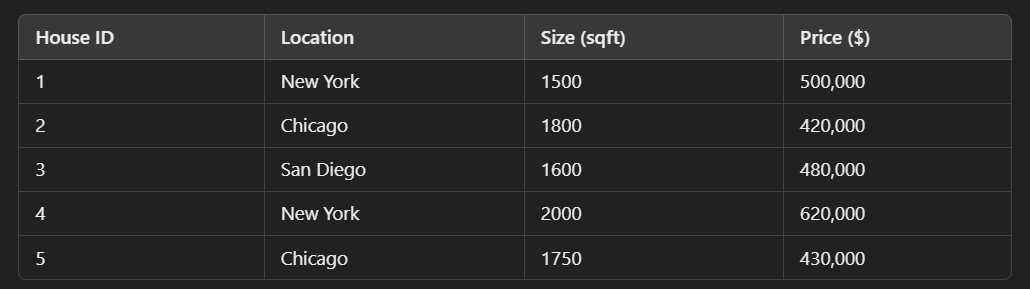

**Step 1: Convert Categorical Variable into Dummy Variables**

Since "Location" is a categorical variable, we convert it into dummy variables.

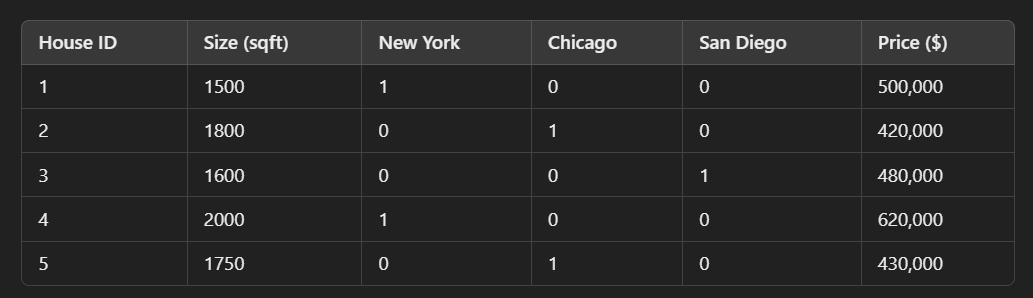

Now, the "Location" feature is represented by three dummy variables:

- "New York"
- "Chicago"
- "San Diego"

Each row has only one of these variables set to 1, while the others are 0.

**Step 2: Why Does It Cause a Problem?**

The problem arises because these three dummy variables are linearly dependent. If we sum them: `New York + Chicago + San Diego = 1`

This means if we know two of them, we can always determine the third one. This introduces perfect multicollinearity, making our regression model unstable.

**Step 3: Solution – Drop One Dummy Variable**

To avoid the dummy variable trap, we drop one dummy variable. Typically, we drop the first category (e.g., "San Diego") and use it as a reference category.

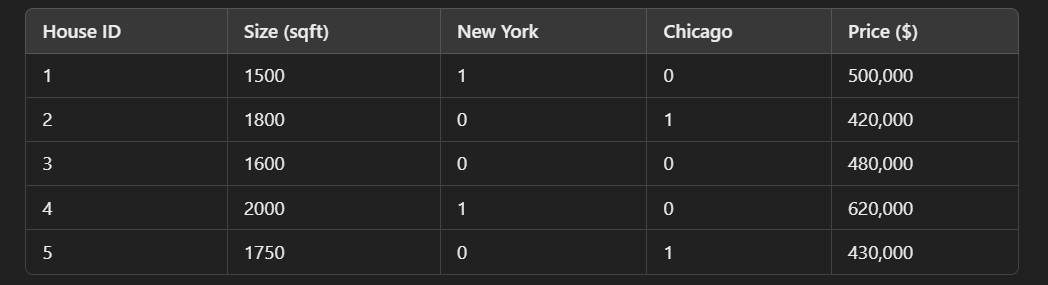

Now, if both "New York" and "Chicago" are 0, the location is assumed to be San Diego.

By dropping one dummy variable, we avoid multicollinearity while still capturing the effect of different locations.

**How to Implement in Python**

If you're using pandas, you can automatically drop one dummy variable using `drop_first=True`:

In [1]:
import pandas as pd

# Sample dataset
data = {'Location': ['New York', 'Chicago', 'San Diego', 'New York', 'Chicago'],
        'Size': [1500, 1800, 1600, 2000, 1750],
        'Price': [500000, 420000, 480000, 620000, 430000]}

df = pd.DataFrame(data)

# Convert categorical variable into dummy variables
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

df

,Size,Price,Location_New York,Location_San Diego
0,1500,500000,True,False
1,1800,420000,False,False
2,1600,480000,False,True
3,2000,620000,True,False
4,1750,430000,False,False


## Ordinal Encoding
Used when categorical values have an inherent order (e.g., Education Level: High School < Bachelor < Master < PhD).

**Pros:** Retains order information.

**Cons:** Can mislead models if the intervals between categories are not equal.

In [5]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master', 'PhD']])
education_levels = [['Bachelor'], ['Master'], ['PhD'], ['High School']]
encoded_education = oe.fit_transform(education_levels)
encoded_education

array([[1.],
       [2.],
       [3.],
       [0.]])

## Target Encoding (Mean Encoding)
- Replaces categories with the mean of the target variable.
- Useful in regression and classification tasks.

**Pros:** Captures useful information.

**Cons:** Prone to overfitting, especially with small datasets.

In [6]:
import numpy as np

df = pd.DataFrame({'City': ['NY', 'LA', 'Chicago', 'LA', 'NY'], 'Loan Approved': [1, 0, 1, 0, 1]})
mean_encoded = df.groupby('City')['Loan Approved'].mean()
df['City_encoded'] = df['City'].map(mean_encoded)
df

,City,Loan Approved,City_encoded
0,NY,1,1.0
1,LA,0,0.0
2,Chicago,1,1.0
3,LA,0,0.0
4,NY,1,1.0


## Frequency Encoding
Replaces each category with its frequency in the dataset.

**Pros:** Helps capture important information without increasing dimensionality.

**Cons:** May not differentiate between categories with similar frequencies.

In [7]:
df = pd.DataFrame({'Fruit': ['Apple', 'Banana', 'Mango', 'Apple', 'Apple', 'Banana']})
df['Fruit_encoded'] = df['Fruit'].map(df['Fruit'].value_counts())
df

,Fruit,Fruit_encoded
0,Apple,3
1,Banana,2
2,Mango,1
3,Apple,3
4,Apple,3
5,Banana,2


## Binary Encoding
Converts categorical values into binary, then splits them into multiple features.

**Pros:** Reduces dimensionality compared to one-hot encoding.

**Cons:** Not as intuitive.

In [11]:
from category_encoders import BinaryEncoder

be = BinaryEncoder()
encoded_df = be.fit_transform(df[['Fruit']])
encoded_df

,Fruit_0,Fruit_1
0,0,1
1,1,0
2,1,1
3,0,1
4,0,1
5,1,0


## Hash Encoding
Hash encoding (also known as Feature Hashing) is a dimensionality reduction technique used to convert categorical data into numerical form using a hashing function. Instead of assigning unique integers (like label encoding) or creating multiple dummy variables (like one-hot encoding), it maps categories to fixed-length numerical feature vectors.

**Why Use Hash Encoding?**

- Efficient for handling high-cardinality categorical features (i.e., categories with many unique values).

- Reduces memory usage compared to one-hot encoding.

- Works well in real-time systems where new categories may appear dynamically.


Cardinality refers to the number of unique values in a categorical feature.
- Low cardinality means the feature has few unique values.
- High cardinality means the feature has many unique values.

### How Does Hash Encoding Work?
1. Select the number of hash buckets (fixed-length output vector).
2. Apply a hash function to each category name.
3. Map the result to one of the buckets (using modulo operation).
4. Assign values to buckets based on the hash result.

**Example of Hash Encoding**
                                      
📌 Suppose we have a categorical feature "Fruit" with four unique values:

- Apple
- Banana
- Grapes
- Mango

If we use One-Hot Encoding, we get:

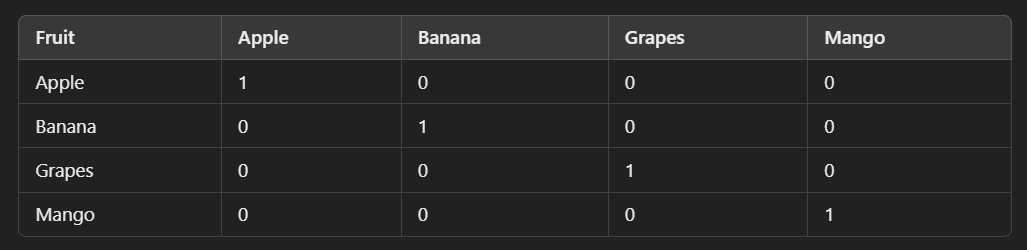

**Problem ❌:**
As the number of categories increases, the number of columns grows exponentially (high-dimensionality issue).

**✅ Hash Encoding Solution:**
We apply a hash function to assign these categories to a fixed number of buckets (e.g., n=2 buckets):

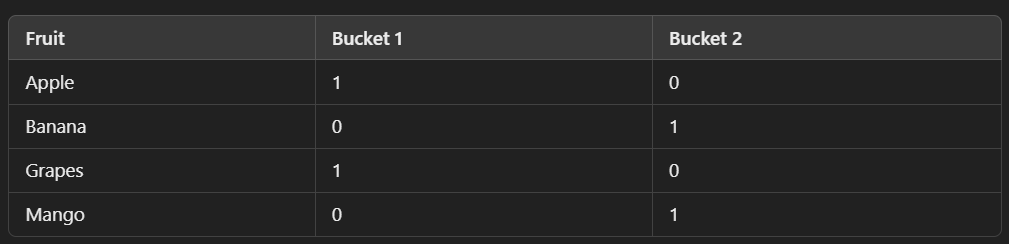

Here, different categories may share the same hash value, leading to hash collisions. While this may introduce noise, it is not a major issue in large datasets.


In [18]:
import pandas as pd
from category_encoders import HashingEncoder

# Sample dataset
df = pd.DataFrame({'Fruit': ['Apple', 'Banana', 'Grapes', 'Mango', 'Apple', 'Banana']})

# Hash Encoding with 2 output features (hash buckets)
he = HashingEncoder(n_components=2)
encoded_df = he.fit_transform(df['Fruit'])

# Show encoded DataFrame
encoded_df

,col_0,col_1
0,1,0
1,1,0
2,1,0
3,0,1
4,1,0
5,1,0


- The categories have been hashed into two numeric columns.

- Same categories map to the same hash values, but different categories might map to the same bucket (hash collisions).

**🔹 Advantages of Hash Encoding**
- ✅ Handles high-cardinality categorical features efficiently.
- ✅ Fixed number of output features, preventing explosion of dimensions.
- ✅ Works well with real-time or unseen data (does not require fitting new mappings).
- ✅ Faster and memory-efficient compared to one-hot encoding.

**🔹 Disadvantages of Hash Encoding**
- ❌ Hash Collisions: Different categories may map to the same hash bucket.
- ❌ Not Interpretable: Unlike one-hot encoding, feature importance is harder to analyze.
- ❌ Less Effective for Small Datasets: Works best in large datasets where patterns emerge despite hash collisions.

**🔹 When to Use Hash Encoding?**
- ✔️ Large datasets with high-cardinality categorical features (e.g., millions of unique values).
- ✔️ Streaming data applications where new categories appear dynamically.
- ✔️ Memory-constrained environments where one-hot encoding is impractical.
- ✔️ Real-time applications where feature engineering must be efficient.

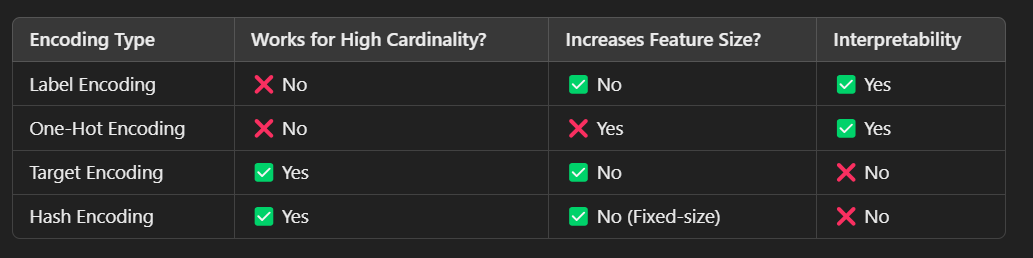

# Practical Considerations
- Handling unseen categories: Some encodings (e.g., Label, Ordinal) will break if an unseen category appears in test data.

- Scalability: One-hot encoding can explode memory if there are too many categories.

- Overfitting: Target encoding can cause overfitting in small datasets.

- Collinearity: One-hot encoding introduces correlation between variables, affecting linear models.

# Summary
Feature encoding is an essential preprocessing step in machine learning. Choosing the right encoding technique depends on the type of categorical variable and the model's requirements. Here’s a quick cheat sheet:

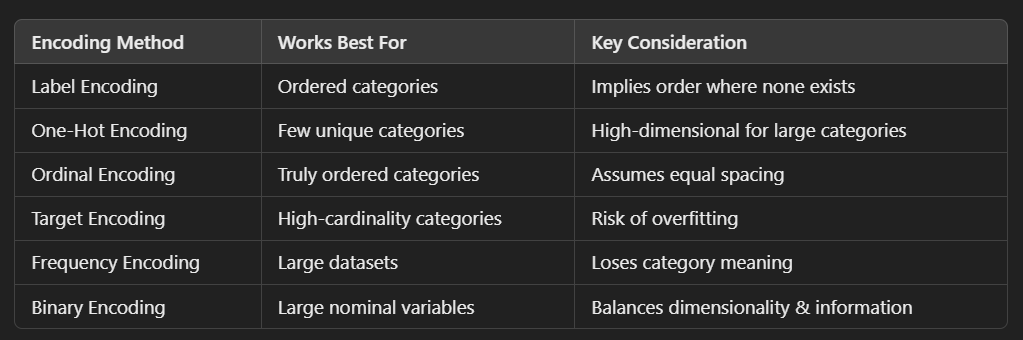

# Example:

In [12]:
import pandas as pd
import seaborn as sns

# Load Titanic dataset
df = sns.load_dataset('titanic')

# Select relevant columns
df = df[['sex', 'embarked', 'class', 'survived']]
df.rename(columns={'class': 'pclass'}, inplace=True)  # Rename 'class' to 'pclass'

df.head()

,sex,embarked,pclass,survived
0,male,S,Third,0
1,female,C,First,1
2,female,S,Third,1
3,female,S,First,1
4,male,S,Third,0


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sex_encoded'] = le.fit_transform(df['sex'])
df[['sex', 'sex_encoded']].head()

,sex,sex_encoded
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1


In [14]:
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)  # Avoid dummy variable trap
df.head()

,sex,pclass,survived,sex_encoded,embarked_Q,embarked_S
0,male,Third,0,1,False,True
1,female,First,1,0,False,False
2,female,Third,1,0,False,True
3,female,First,1,0,False,True
4,male,Third,0,1,False,True


In [15]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder(categories=[['Third', 'Second', 'First']])  # Define order
df['pclass_encoded'] = ordinal_encoder.fit_transform(df[['pclass']])
df[['pclass', 'pclass_encoded']].head()

,pclass,pclass_encoded
0,Third,0.0
1,First,2.0
2,Third,0.0
3,First,2.0
4,Third,0.0


In [16]:
mean_encoding = df.groupby('pclass')['survived'].mean()
df['pclass_target_encoded'] = df['pclass'].map(mean_encoding)
df[['pclass', 'pclass_target_encoded']].head()

C:\Users\SAURABH PRAKASH\AppData\Local\Temp\ipykernel_3812\3965599916.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_encoding = df.groupby('pclass')['survived'].mean()


,pclass,pclass_target_encoded
0,Third,0.242363
1,First,0.629630
2,Third,0.242363
3,First,0.629630
4,Third,0.242363


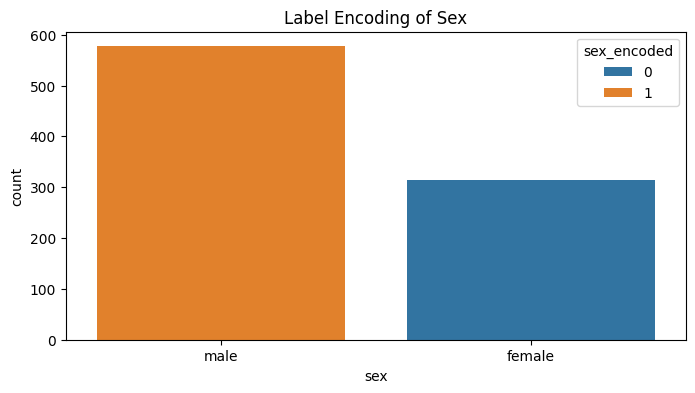

In [17]:
# Visualize the Encoded Data

import matplotlib.pyplot as plt

# Compare label encoding vs original
plt.figure(figsize=(8, 4))
sns.countplot(x=df['sex'], hue=df['sex_encoded'])
plt.title('Label Encoding of Sex')
plt.show()


# Dummy Variable trap